In [1]:
#| default_exp Home

<img src="images/peshbeen_logo_transparent.svg" style="display:block; width:100%; max-width:1500px; margin:0 auto;" />

**peshbeen** is an easy-to-use Python package designed to bridge the gap between traditional statistical forecasting and modern machine learning. In Kurdish, "pesh" means "front" and "been" means "to see/be"; together, they translate to "foresight". The library provides a unified interface spanning a wide range of models: from ARIMA and Vector Autoregressions to scikit-learn regressors and gradient-boosted trees (XGBoost, LightGBM, CatBoost). Whether you are working with univariate time series or multivariate time series forecasts, peshbeen automates the heavy lifting of feature engineering, lag generation, and stationarity transformations.

## Key Features

- **Unified API:** Train any model using a simple `.fit(df)` and `.forecast(H)` workflow, eliminating the need for manual feature/target splitting.

- **Model Agnostic:** Supports a wide range of forecasting models, including ETS, ARIMA, Vector Autoregressions, scikit-learn regressors, and gradient-boosted trees (XGBoost, LightGBM, CatBoost).

- **Automatic Feature Engineering:** User can specify the key following parameters to automatically generate features:
  - `lags`: List of lag periods to create lag features.
  - `rolling_windows`: List of window sizes for rolling statistics to create rolling features (e.g., rolling mean, rolling std, rolling quantiles).
  - `trend removal`: Option to automatically difference the data or de-trend it using global trend, local trend, or piecewise linear trend. For piecewise linear trend, the user can specify the indexes of the breakpoints. For local trend, the user can pass ETS parameters to fit a local ETS model and use its fitted values as the local trend.
  - `boxcox`: Option to apply Box-Cox transformation to target variable to stabilize variance.

- **Multivariate Forecasting:** Supports forecasting with multiple target variables and exogenous regressors, making it suitable for multivariate forecasting tasks where relationships between variables can be leveraged for improved accuracy.

- **Probabilistic Forecasting:** Enables probabilistic forecasting through a simple two-step workflow. First, call `calibrate` with a held-out portion (calibration data) of your dataset — peshbeen uses the residuals at each horizon to fit the uncertainty model. Then call `sample` to generate forecast scenarios and prediction intervals, giving you a full picture of forecast uncertainty for risk assessment and decision-making.

    Four methods are implemented for generating probabilistic forecasts: 

    - **Empirical & Kernel Density Estimation (KDE):** This method generates probabilistic forecasts by resampling from the empirical distribution of the residuals. By adding these resampled residuals to the point forecasts, we can create a distribution of possible future values. `KDE` can be applied to these resampled forecasts to obtain a smooth probability density function, which can then be used to derive prediction intervals and quantiles.

    - **Correlated Bootstrap:** This method generates probabilistic forecasts by resampling from the residuals while preserving the correlation structure across different forecast horizons. By resampling entire rows of residuals (i.e., all horizons together), we can maintain the temporal dependencies and correlations between forecast errors at different horizons, leading to more realistic forecast scenarios.

    - **Conformal Prediction:** This method generates probabilistic forecasts by applying conformal prediction techniques to the residuals. By calculating nonconformity scores based on the residuals and using them to determine prediction intervals.

- **Hyperparameter Tuning:** Provides built-in support for hyperparameter tuning using Hyperopt and Optuna, allowing users to optimize model performance with minimal effort.

## Installation

Run the following command in your terminal to install the latest version from PyPI:

```bash
pip install peshbeen
```

If you are using a Conda environment, you can still install peshbeen via pip once your environment is active:

```bash
conda activate your_env_name
pip install peshbeen
```

## Quick Start Example

In [2]:
from peshbeen.datasets import load_wales_admissions # addmissions to E&A hospitals in Wales
from peshbeen.models import ml_forecaster
from peshbeen.transformations import rolling_mean, rolling_std, expanding_mean
from xgboost import XGBRegressor
load_wales_admissions["day_of_week"] = load_wales_admissions.index.dayofweek # add day of week as a feature
load_wales_admissions["month"] = load_wales_admissions.index.month # add month as a feature to capture seasonality
load_wales_admissions["day_of_month"] = load_wales_admissions.index.day # add day of month as a feature to capture seasonality
# split the data into train and test sets
train = load_wales_admissions[:-30]
test = load_wales_admissions[-30:]
cat_variables = ["day_of_week", "month", "day_of_month"]
transforms = [rolling_mean(window_size= 28, shift=7), rolling_std(window_size=28), expanding_mean()] 
# import linear regression from sklearn
from sklearn.linear_model import LinearRegression
ml_linear = ml_forecaster(model=XGBRegressor(),
              target_col='admissions', lags = 6,
              cat_variables=cat_variables,
              lag_transform=transforms)
ml_linear.fit(train)
forecasts = ml_linear.forecast(H=30, exog=test[cat_variables])

/Users/aslanm/Desktop/my_desk/peshbeen/.venv/lib/python3.14/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


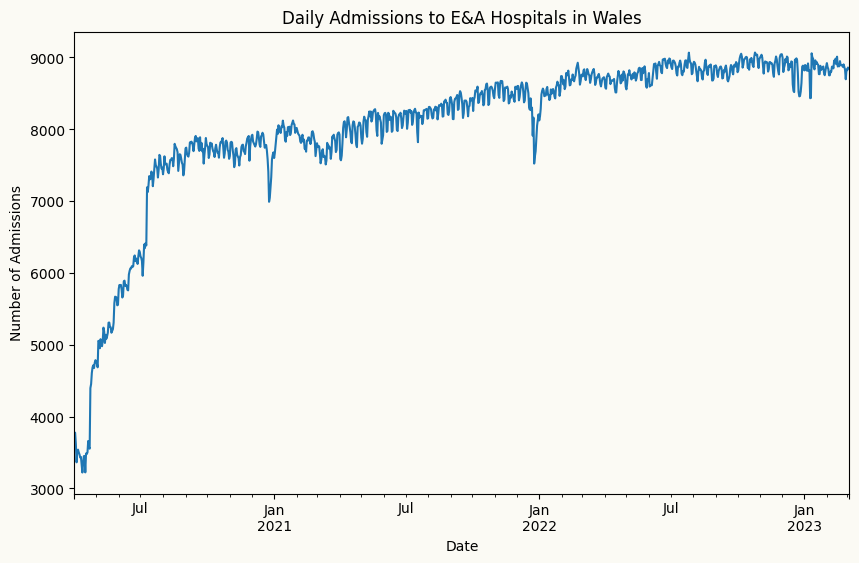

In [3]:
## Plot the historical data
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = "#FBFAF4"
plt.rcParams['axes.facecolor'] = "#FBFAF4"
load_wales_admissions["admissions"].plot(figsize=(10, 6), label='Admissions')
plt.title("Daily Admissions to E&A Hospitals in Wales")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")
plt.show()

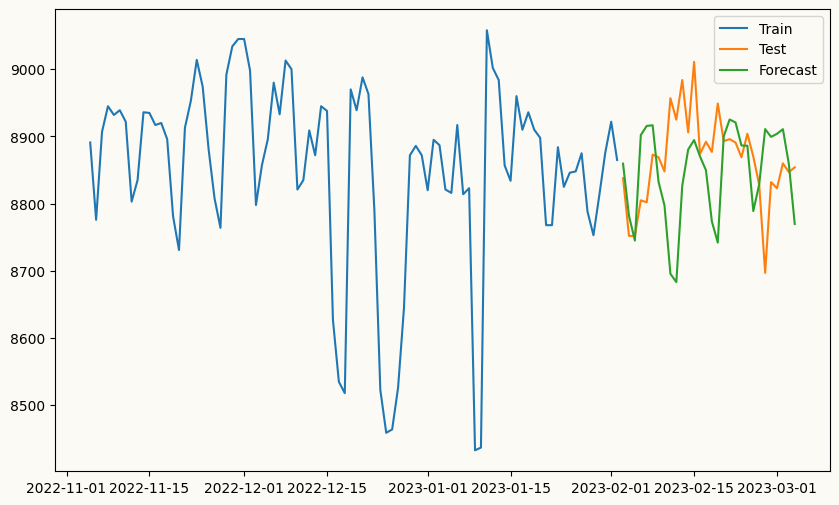

In [4]:
# plot the forecast against the actual values
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train')
plt.plot(test.index, test['admissions'], label='Test')
plt.plot(test.index, forecasts, label='Forecast')
plt.legend()
plt.show()